
# Compare NN predictions vs TDS simulation using run_scan outputs

This notebook loads the scan results (M, D, Pg) from `scan_parameters.csv`,
sets them in an ANDES simulation, runs TDS, and compares the extracted metrics
against the NN predicted outputs.


In [1]:

from pathlib import Path
import numpy as np
import pandas as pd
import yaml
import torch
import andes

from data_generation.extract_metrics import extract_simulation_row
from scheduling.utils import load_scaler, build_torch_model


(CVXPY) Feb 03 10:03:47 PM: Encountered unexpected exception importing solver MPAX:
RuntimeError('This version of jaxlib was built using AVX instructions, which your CPU and/or operating system do not support. This error is frequently encountered on macOS when running an x86 Python installation on ARM hardware. In this case, try installing an ARM build of Python. Otherwise, you may be able work around this issue by building jaxlib from source.')



## Config
Adjust paths below to point to your `scan_parameters.csv` and configs.


In [59]:

# Paths
SCAN_CSV = Path("convex_opt/tests/scan_parameters.csv")
SIM_CFG = Path("experiments/generation.yaml")
COST_CFG = Path("scheduling/mtlsh_convex.yaml")

# Select which scan index to use (row index in scan_parameters.csv)
SCAN_INDEX = 0


In [60]:

# Load configs
with SIM_CFG.open("r", encoding="utf-8") as f:
    sim_cfg = yaml.safe_load(f)
with COST_CFG.open("r", encoding="utf-8") as f:
    cost_cfg = yaml.safe_load(f)

# Load scan results
scan_df = pd.read_csv(SCAN_CSV)
scan_df


,record_type,index,index_1based,is_ibr,Pg_nn,Pg_baseline,Pg_delta,M,D
0,generator,0,1,1,4.340108,10.400000,6.059892,NaN,NaN
1,generator,1,2,0,6.055285,4.288787,-1.766498,NaN,NaN
2,generator,2,3,0,6.055285,4.288787,-1.766498,NaN,NaN
3,generator,3,4,0,6.055285,4.288787,-1.766498,NaN,NaN
4,generator,4,5,0,5.500000,4.288787,-1.211213,NaN,NaN
5,generator,5,6,1,6.788193,6.970000,0.181807,NaN,NaN
6,generator,6,7,0,5.950000,4.288787,-1.661213,NaN,NaN
7,generator,7,8,1,3.134298,5.640000,2.505702,NaN,NaN
8,generator,8,9,1,7.458981,8.650000,1.191019,NaN,NaN
9,generator,9,10,0,6.055285,4.288787,-1.766498,NaN,NaN



## Extract M, D, Pg from scan CSV
We use the `generator` rows for Pg and the `ibr` rows for M/D.


In [61]:
# Generator Pg (NN dispatch)
pg_rows = scan_df[scan_df["record_type"] == "generator"].copy()
pg_rows = pg_rows.sort_values("index")
Pg_nn = pg_rows["Pg_nn"].to_numpy(dtype=float)

# IBR M, D (map by index_1based -> REGCV1 order)
ibr_rows = scan_df[scan_df["record_type"] == "ibr"].copy()
ibr_rows = ibr_rows.sort_values("index")
M_vec = ibr_rows["M"].to_numpy(dtype=float)
D_vec = ibr_rows["D"].to_numpy(dtype=float)

Pg_nn, M_vec, D_vec


(array([4.34010795, 6.0552849 , 6.0552849 , 6.0552849 , 5.5       ,
        6.78819332, 5.94999992, 3.13429839, 7.45898081, 6.0552849 ]),
 array([3.82366063, 4.28719374, 3.60503717, 4.23989781]),
 array([2.25916919, 2.25411506, 1.234818  , 2.93921757]))


## Run TDS with injected M, D, Pg
This mirrors `run_sim_extract_ed.py` but uses Pg/M/D from scan results.


In [82]:
# Load ANDES system
case_path = sim_cfg["case"]
ss = andes.load(case_path, setup=False)
ss.config.freq = float(50)

# Apply base load scale
base_scale = float(sim_cfg.get("base_scale", 1.0))
for uid in range(ss.PQ.n):
    ss.PQ.p0.v[uid] = ss.PQ.p0.v[uid] * base_scale
    ss.PQ.q0.v[uid] = ss.PQ.q0.v[uid] * base_scale
for uid in range(ss.PV.n):
    ss.PV.p0.v[uid] = ss.PV.p0.v[uid] * base_scale
    ss.PV.q0.v[uid] = ss.PV.q0.v[uid] * base_scale

# Capture BEFORE step values
pq_p_before = np.asarray(ss.PQ.p0.v, dtype=float).copy()
pq_q_before = np.asarray(ss.PQ.q0.v, dtype=float).copy()

# Set M, D for IBRs (REGCV1 order)
if len(M_vec) != ss.REGCV1.n or len(D_vec) != ss.REGCV1.n:
    raise ValueError(f"scan CSV IBR count {len(M_vec)} does not match REGCV1.n={ss.REGCV1.n}")
ss.REGCV1.M.v = M_vec
ss.REGCV1.D.v = D_vec

# Setup and power flow
ss.PQ.config.p2p = 1
ss.PQ.config.q2q = 1
ss.PQ.config.p2z = 0
ss.PQ.config.q2z = 0
ss.PQ.pq2z = 0

ss.TGOV1N.u.v = 0.0  # No AGC input

ss.setup()
ss.PFlow.run()

# Configure and run TDS
ss.TDS.config.no_tqdm = bool(sim_cfg["tds"].get("no_tqdm", True))
ss.TDS.config.criteria = int(sim_cfg["tds"].get("criteria", 0))
ss.TDS.config.tol = float(sim_cfg["tds"].get("tol", 1e-6))
ss.TDS.config.tstep = float(sim_cfg["tds"]["t_step"])
ss.TDS.config.tf = float(sim_cfg["tds"]["t_step"])
ss.TDS.config.fixt = int(sim_cfg["tds"].get("fixt", 0))
ss.TDS.config.method = str(sim_cfg["tds"].get("method", "backeuler"))
ss.TDS.config.honest = int(sim_cfg["tds"].get("honest", 0))
ss.TDS.config.max_iter = int(sim_cfg["tds"].get("max_iter", 35))
ss.TDS.config.shrinkt = int(sim_cfg["tds"].get("shrinkt", 1))

# Apply load step (override default 1.0 if you want nonzero delta)
step_scale = float(sim_cfg.get("step_scale", 0.98))
ss.TDS.init()
ss.TDS.run()

for uid in range(ss.PQ.n):
    p = ss.PQ.p0.v[uid] * step_scale
    q = ss.PQ.q0.v[uid] * step_scale
    ss.PQ.p0.v[uid], ss.PQ.Ppf.v[uid] = p, p
    ss.PQ.q0.v[uid], ss.PQ.Qpf.v[uid] = q, q

# Apply Pg to PV and Slack in the same order as scan file (PV then Slack)
if len(Pg_nn) != ss.PV.n + ss.Slack.n:
    raise ValueError("scan CSV generator count does not match PV+Slack")
for i, Pg in enumerate(Pg_nn):
    if i < ss.PV.n:
        ss.PV.p0.v[i] = Pg
    else:
        slack_i = i - ss.PV.n
        ss.Slack.p0.v[slack_i] = Pg

Pg_nn_ibrs = scan_df[scan_df["is_ibr"] == 1].Pg_nn.dropna().to_numpy(dtype=float)
Pg_nn_ibrs_baseline = ss.REGCV1.Pref.v.copy()
ss.REGCV1.Pref.v = Pg_nn_ibrs
Pg_nn_genrous = scan_df[scan_df["is_ibr"] == 0].Pg_nn.dropna().to_numpy(dtype=float)
Pg_nn_genrous_baseline = ss.GENROU.Pe.v.copy()
ss.GENROU.te.v = Pg_nn_genrous
ss.StaticGen.p0.v = Pg_nn_genrous
ss.TGOV1N.paux0.v = Pg_nn_genrous

ss.TDS.config.tf = float(sim_cfg["tds"]["t_end"])
success = bool(ss.TDS.run())
ss.TDS.load_plotter()

# Capture AFTER step values
pq_p_after = np.asarray(ss.PQ.Ppf.v, dtype=float).copy()
pq_q_after = np.asarray(ss.PQ.Qpf.v, dtype=float).copy()

row = extract_simulation_row(
    ss=ss,
    base_load_scale=base_scale,
    load_step_scale=step_scale,
    load_step_time=float(sim_cfg["tds"]["load_step_time"]),
    pq_names=list(ss.PQ.name.v) if ss.PQ.n else [],
    pq_p_before=pq_p_before,
    pq_q_before=pq_q_before,
    pq_p_after=pq_p_after,
    pq_q_after=pq_q_after,
    M_vec=M_vec,
    D_vec=D_vec,
    success=success,
    plotter_csv=None,
)

row


GENROU (xl <= xd2) out of typical upper limit.

   idx     | values | limit
-----------+--------+------
 GENROU_2  | 0.005  | 0.004
 GENROU_3  | 0.004  | 0.000
 GENROU_4  | 0.002  | 0.000
 GENROU_5  | 0.005  | 0.000
 GENROU_7  | 0.003  | 0.000
 GENROU_10 | 0.000  | 0.000


Suspect initialization issue! Simulation may crash!

        Name          | Var. Value | Eqn. Mismatch
----------------------+------------+--------------
 LL_y TGOV1N TGOV1 2  | 0          | 0.836        
 LL_y TGOV1N TGOV1 3  | 0          | 0.844        
 LL_y TGOV1N TGOV1 4  | 0          | 1.175        
 LL_y TGOV1N TGOV1 5  | 0          | 1.080        
 LL_y TGOV1N TGOV1 7  | 0          | 1.025        
 LL_y TGOV1N TGOV1 10 | 0          | 1.199        


Initialization failed!!
If you are developing a new model, check the initialization with
   andes -v 10 run -r tds --init data_generation/andes_cases/ieee39_full_ibrs.xlsx
Otherwise, check the variables that are initialized out of limits.


AttributeError: 'StaticGen' object has no attribute 'p0'

In [80]:
Pg_nn_ibrs, Pg_nn_ibrs_baseline

(array([4.34010795, 6.78819332, 3.13429839, 7.45898081]),
 array([4.36086385, 6.86999998, 3.21521338, 7.64783381]))

In [77]:
ss.TGOV1N.as_df()

,idx,u,name,syn,Tn,wref0,R,VMAX,VMIN,T1,T2,T3,Dt
uid,,,,,,,,,,,,,
0,TGOV1_2,0.0,TGOV1_2,GENROU_2,0.0,1.0,0.005981,8.77800,0.8360,0.05,1.0,2.1,0.0
1,TGOV1_3,0.0,TGOV1_3,GENROU_3,0.0,1.0,0.005926,8.85885,0.8437,0.05,1.0,2.1,0.0
2,TGOV1_4,0.0,TGOV1_4,GENROU_4,0.0,1.0,0.004256,12.33540,1.1748,0.05,1.0,2.1,0.0
3,TGOV1_5,0.0,TGOV1_5,GENROU_5,0.0,1.0,0.004629,11.34210,1.0802,0.05,1.0,2.1,0.0
4,TGOV1_7,0.0,TGOV1_7,GENROU_7,0.0,1.0,0.004877,10.76460,1.0252,0.05,1.0,2.1,0.0
5,TGOV1_10,0.0,TGOV1_10,GENROU_10,0.0,1.0,0.004170,12.58950,1.1990,0.05,1.0,2.1,0.0


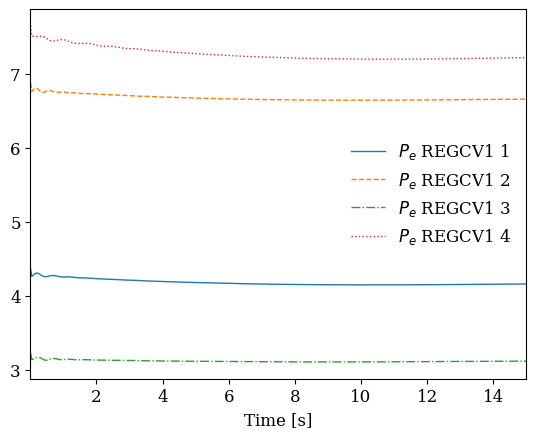

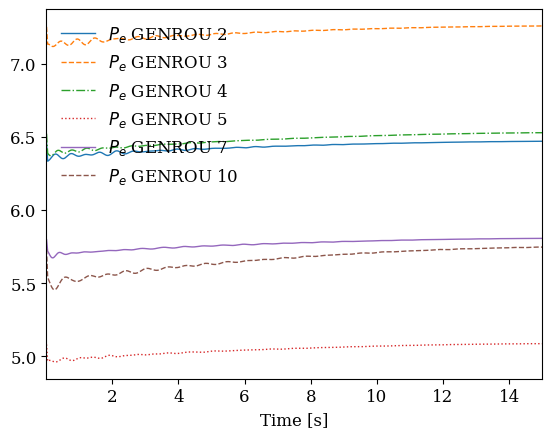

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='Time [s]'>)

In [81]:
%matplotlib inline
idx = ss.TDS.plotter.find("Pe REGCV1", idx_only=True)
ss.TDS.plotter.plot(yidx=idx, legend=True)
idx = ss.TDS.plotter.find("Pe GENROU", idx_only=True)
ss.TDS.plotter.plot(yidx=idx, legend=True)

In [71]:
Pg_nn_genrous, Pg_nn_genrous_baseline

(array([6.0552849 , 6.0552849 , 6.0552849 , 5.5       , 5.94999992,
        6.0552849 ]),
 array([6.45999998, 7.24999998, 6.51999998, 5.07999998, 5.79999998,
        5.73110424]))


## Compare with NN predictions
We recompute NN output from the same features and compare.


In [57]:

# Build features as in run_scan
from scheduling.utils import build_features

features = build_features(
    ss,
    base_scale=1,
    step_scale=0.5,
    load_step_time=float(sim_cfg["tds"]["load_step_time"]),
    M_vec=M_vec,
    D_vec=D_vec,
)

x_features = cost_cfg.get("features", {}).get("x_features")
feat_vec = np.array([features[name] for name in x_features], dtype=float).reshape(1, -1)

x_scaler = load_scaler(cost_cfg.get("scalers", {}).get("x_scaler_path"), name="x_scaler")
y_scaler = load_scaler(cost_cfg.get("scalers", {}).get("y_scaler_path"), name="y_scaler")

feat_scaled = x_scaler.transform(feat_vec) if x_scaler is not None else feat_vec

model_cfg = cost_cfg.get("model", {})
model = build_torch_model(model_cfg)
state_path = Path(model_cfg.get("state_dict", ""))
if state_path.is_dir():
    state_path = state_path / "vis_mlp_state_dict.pt"
state = torch.load(state_path, map_location="cpu")
model.load_state_dict(state)
model.eval()

with torch.no_grad():
    pred_scaled = model(torch.tensor(feat_scaled, dtype=torch.float32)).cpu().numpy().reshape(-1)

pred_unscaled = y_scaler.inverse_transform(pred_scaled.reshape(1, -1)).reshape(-1)

pred_scaled, pred_unscaled

/Applications/anaconda3/envs/GESTURE/lib/python3.9/site-packages/sklearn/base.py:376: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.6.1 when using version 1.4.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


(array([0.784865  , 0.83279663, 0.0021495 , 0.9102391 , 0.2361578 ,
        0.34903097, 0.36046043, 0.3944128 ], dtype=float32),
 array([ 6.8104017e-01, -6.5925360e-02,  1.9248215e-03,  1.3931584e+00,
        -2.3154948e+00, -2.3247094e+00, -1.7907619e+00, -3.0630183e+00],
       dtype=float32))


## Side-by-side comparison


In [58]:

# compare predicted NN outputs vs extracted sim row metrics
metrics = cost_cfg.get("features", {}).get("y_features", [])

sim_vals = np.array([row.get(m, np.nan) for m in metrics], dtype=float)

comp = pd.DataFrame({
    "metric": metrics,
    "nn_pred": pred_unscaled,
    "sim": sim_vals,
    "error": sim_vals - pred_unscaled,
})
comp


,metric,nn_pred,sim,error
0,rocof_max_COI,0.681040,3.187823,2.506783
1,rocof_min_COI,-0.065925,-0.301725,-0.235800
2,devdown_COI,0.001925,0.000000,-0.001925
3,devup_COI,1.393158,0.620479,-0.772680
4,Delta_P_IBR_1,-2.315495,-1.019668,1.295827
5,Delta_P_IBR_2,-2.324709,-1.099186,1.225524
6,Delta_P_IBR_3,-1.790762,-0.824891,0.965871
7,Delta_P_IBR_4,-3.063018,-1.341033,1.721986


In [14]:

# Optional: quick bar plot
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(comp["metric"], comp["nn_pred"], label="NN pred", marker="o")
ax.plot(comp["metric"], comp["sim"], label="Sim", marker="x")
ax.set_xticklabels(comp["metric"], rotation=45, ha="right")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()


/var/folders/1r/8fr05d2d32dgq5pcj0q3vzl80000gn/T/ipykernel_72946/1797247031.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(comp["metric"], rotation=45, ha="right")
